In [1]:
!pip install pandas matplotlib seaborn plotly nbformat


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

# Load the 2024 dataset with the correct encoding
df = pd.read_csv('Most Streamed Spotify Songs 2024.csv', encoding='latin1')

# Inspect the first few rows
print("--- First 5 Rows ---")
display(df.head())

# Check for missing values and data types
print("\n--- Dataset Information ---")
df.info()

--- First 5 Rows ---


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1



--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   str    
 1   Album Name                  4600 non-null   str    
 2   Artist                      4595 non-null   str    
 3   Release Date                4600 non-null   str    
 4   ISRC                        4600 non-null   str    
 5   All Time Rank               4600 non-null   str    
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   str    
 8   Spotify Playlist Count      4530 non-null   str    
 9   Spotify Playlist Reach      4528 non-null   str    
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   str    
 12  YouTube Likes               4285 non-null   str    
 13  TikTok Posts   

In [3]:
# Print all column names exactly as they appear in the CSV
print(list(df.columns))

['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track']


In [4]:
import numpy as np

# 1. Convert 'Release Date' to datetime and extract the Year
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year

# 2. List the columns that should be numbers but might have commas
numeric_cols = [
    'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 
    'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 
    'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 
    'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 
    'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 
    'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 
    'Shazam Counts', 'TIDAL Popularity'
]

# 3. Remove commas and convert to numeric
for col in numeric_cols:
    if col in df.columns:
        # Remove commas and any spaces
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = df[col].str.strip()
        # Convert to numbers, turning bad data into NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Drop rows where we don't have critical data (Track Name, Artist, Streams, or Year)
df.dropna(subset=['Track', 'Artist', 'Spotify Streams', 'Release Year'], inplace=True)

# 5. Verify the changes
print("--- Cleaned Data Info ---")
df.info()

print("\n--- Check for remaining missing values in our main columns ---")
print(df[['Spotify Streams', 'YouTube Views', 'TikTok Views', 'Release Year']].isnull().sum())

--- Cleaned Data Info ---
<class 'pandas.DataFrame'>
Index: 4487 entries, 0 to 4599
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Track                       4487 non-null   str           
 1   Album Name                  4487 non-null   str           
 2   Artist                      4487 non-null   str           
 3   Release Date                4487 non-null   datetime64[us]
 4   ISRC                        4487 non-null   str           
 5   All Time Rank               4487 non-null   int64         
 6   Track Score                 4487 non-null   float64       
 7   Spotify Streams             4487 non-null   float64       
 8   Spotify Playlist Count      4467 non-null   float64       
 9   Spotify Playlist Reach      4465 non-null   float64       
 10  Spotify Popularity          3781 non-null   float64       
 11  YouTube Views               4218 non-null   fl

In [5]:
# Fill missing values in platform metrics with 0
# This assumes the song wasn't present or tracked on that platform
df['YouTube Views'] = df['YouTube Views'].fillna(0)
df['TikTok Views'] = df['TikTok Views'].fillna(0)
df['YouTube Likes'] = df['YouTube Likes'].fillna(0)
df['TikTok Likes'] = df['TikTok Likes'].fillna(0)

print("Missing values filled successfully!")

Missing values filled successfully!


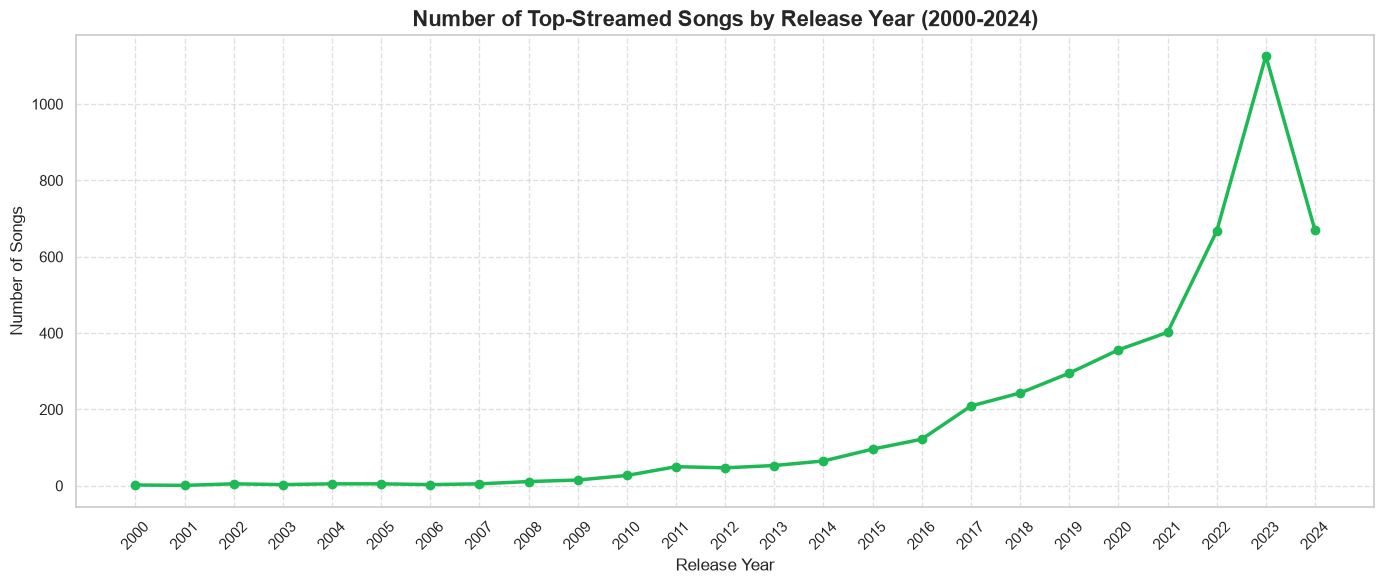

In [6]:
# Count how many songs were released each year
songs_per_year = df['Release Year'].value_counts().sort_index()

# Filter to only show years from 2000 onwards (older years have very few songs and will clutter the chart)
songs_per_year = songs_per_year[songs_per_year.index >= 2000]

plt.figure(figsize=(14, 6))
plt.plot(songs_per_year.index, songs_per_year.values, marker='o', color='#1DB954', linewidth=2.5, markersize=6)

# Add titles and labels
plt.title('Number of Top-Streamed Songs by Release Year (2000-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

# Force x-axis to show every year from 2000 to 2024
plt.xticks(range(2000, 2025), rotation=45)

plt.tight_layout()
plt.show()

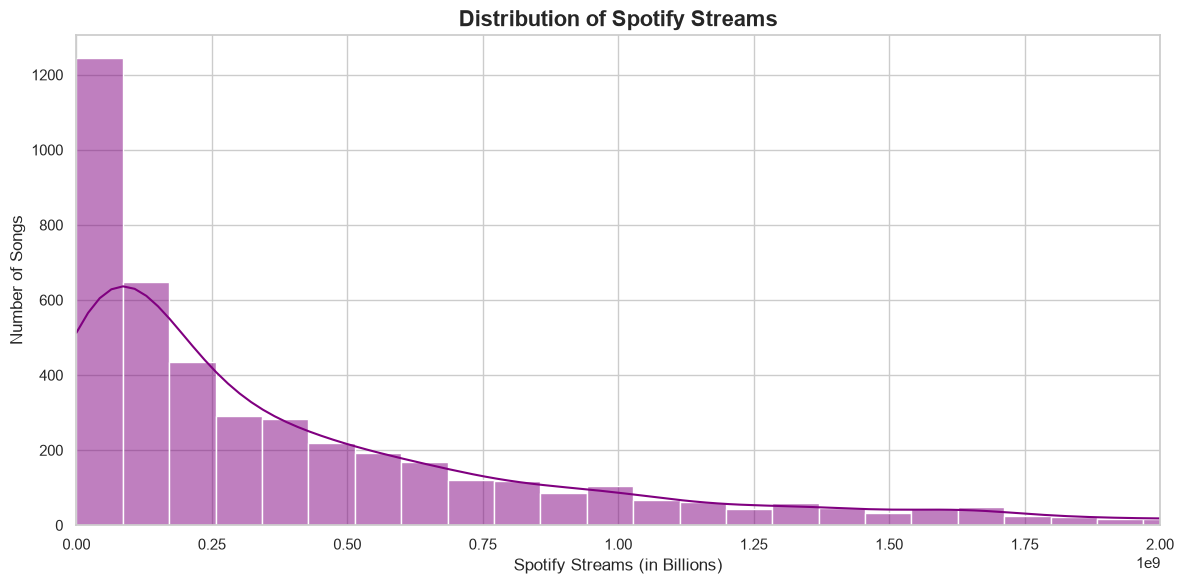

In [7]:
plt.figure(figsize=(12, 6))

# Create a histogram with 50 bins and a KDE (smooth curve) on top
sns.histplot(df['Spotify Streams'], bins=50, kde=True, color='purple')

plt.title('Distribution of Spotify Streams', fontsize=16, fontweight='bold')
plt.xlabel('Spotify Streams (in Billions)', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)

# Let's limit the x-axis to 2 billion so the chart isn't squished by extreme outliers
plt.xlim(0, 2000000000) 

plt.tight_layout()
plt.show()

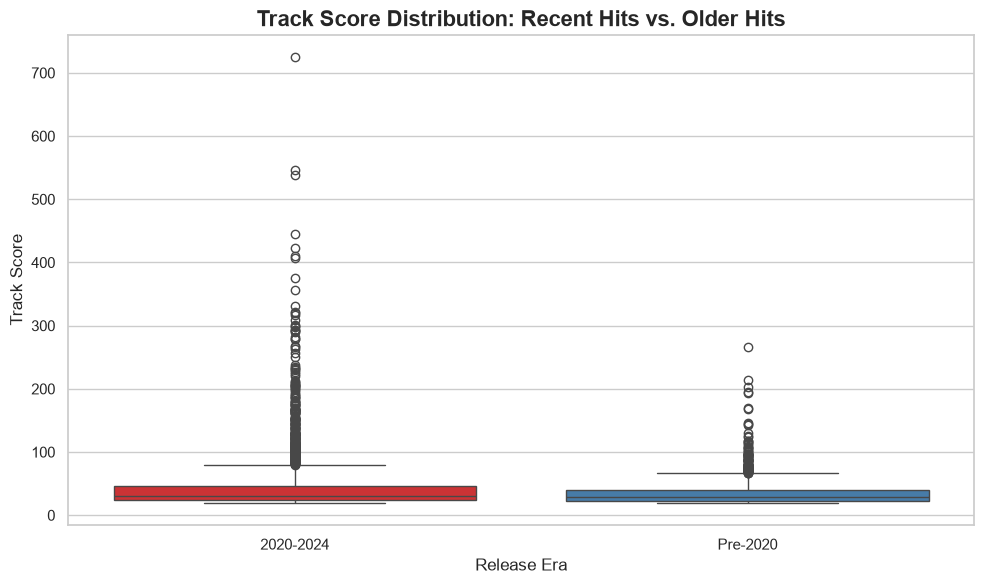

In [8]:
# Create a new column to group songs by era
df['Era'] = df['Release Year'].apply(lambda x: '2020-2024' if x >= 2020 else 'Pre-2020')

plt.figure(figsize=(10, 6))

# Create a boxplot comparing Track Score for recent vs older songs
sns.boxplot(x='Era', y='Track Score', data=df, hue='Era', palette='Set1', legend=False)

plt.title('Track Score Distribution: Recent Hits vs. Older Hits', fontsize=16, fontweight='bold')
plt.xlabel('Release Era', fontsize=12)
plt.ylabel('Track Score', fontsize=12)

# Optional: If you still see extreme outliers squishing the box, uncomment the line below
# plt.ylim(0, 150) 

plt.tight_layout()
plt.show()

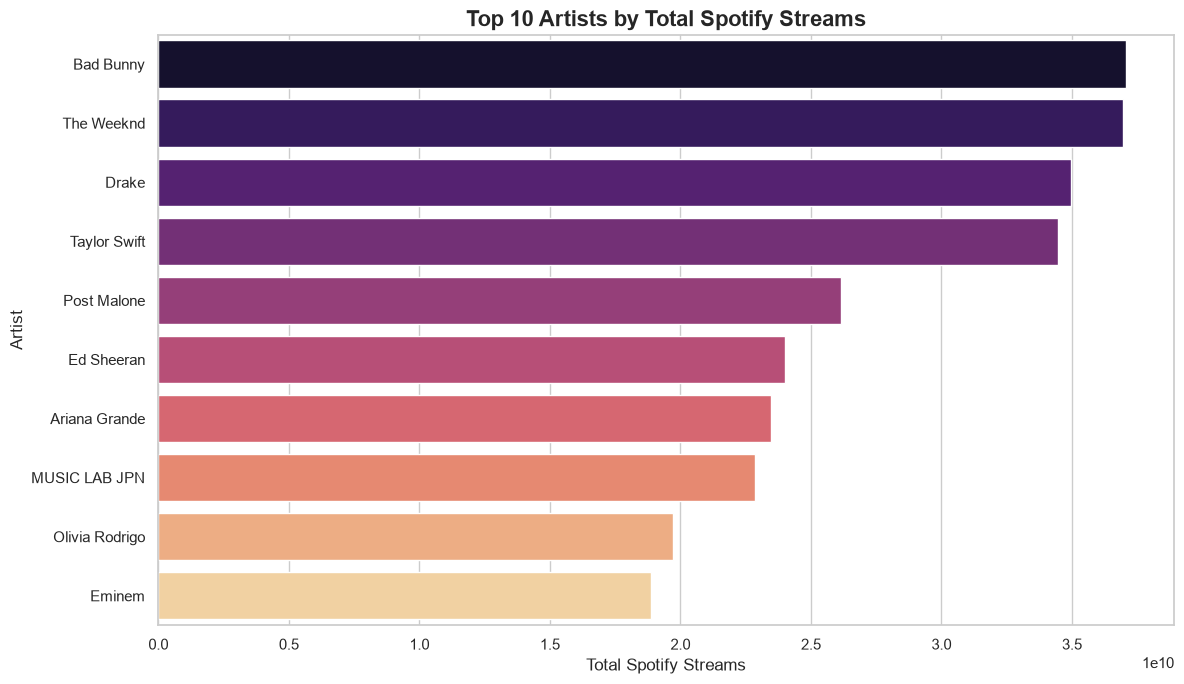

In [9]:
# First, we need to group the data by Artist and sum up their Spotify Streams
artist_streams = df.groupby('Artist')['Spotify Streams'].sum().reset_index()

# Sort them from highest to lowest and take the top 10
top_10_artists = artist_streams.sort_values(by='Spotify Streams', ascending=False).head(10)

# Create the barplot
plt.figure(figsize=(12, 7))

# We use hue='Artist' and legend=False to avoid the deprecation warning
sns.barplot(x='Spotify Streams', y='Artist', data=top_10_artists, hue='Artist', palette='magma', legend=False)

plt.title('Top 10 Artists by Total Spotify Streams', fontsize=16, fontweight='bold')
plt.xlabel('Total Spotify Streams', fontsize=12)
plt.ylabel('Artist', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
# Create a clean DataFrame specifically for this chart
# We drop rows where Spotify Popularity or TikTok Views are missing (NaN)
scatter_df = df.dropna(subset=['Spotify Popularity', 'TikTok Views']).copy()

# Create the interactive scatter plot
fig = px.scatter(
    scatter_df, 
    x='TikTok Views', 
    y='Spotify Popularity',
    color='Explicit Track',
    hover_data=['Track', 'Artist', 'Spotify Streams'],
    title='Interactive: TikTok Views vs. Spotify Popularity',
    labels={
        'TikTok Views': 'TikTok Views (Billions)', 
        'Spotify Popularity': 'Spotify Popularity Score (0-100)',
        'Explicit Track': 'Explicit?'
    },
    color_continuous_scale=px.colors.sequential.Viridis,
    opacity=0.7
)

# Show the interactive chart
fig.show()

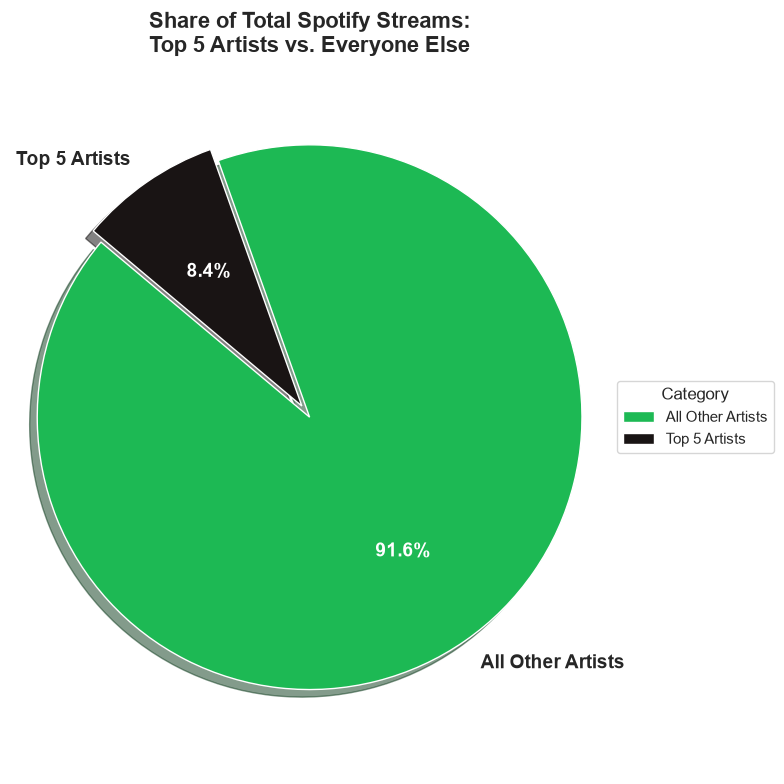

In [13]:
# 1. Get the top 5 artists by total streams
top_5_artists = df.groupby('Artist')['Spotify Streams'].sum().nlargest(5).index

# 2. Create a new column marking whether the song is by a top 5 artist or not
df['Top_5_Artist'] = df['Artist'].apply(lambda x: 'Top 5 Artists' if x in top_5_artists else 'All Other Artists')

# 3. Group by this new column and SUM the Spotify Streams
pie_data = df.groupby('Top_5_Artist')['Spotify Streams'].sum()

plt.figure(figsize=(8, 8))

# Create the pie chart
wedges, texts, autotexts = plt.pie(
    pie_data.values, 
    labels=pie_data.index, 
    autopct='%1.1f%%',  
    startangle=140,     
    colors=['#1DB954', '#191414'], # Spotify Green and Black
    explode=(0.05, 0),  
    shadow=True,
    textprops={'fontsize': 14, 'fontweight': 'bold'} # Removed white color
)

# Change the percentage text color to white so it pops against the dark slices
for autotext in autotexts:
    autotext.set_color('white')

# Add a clear legend
plt.legend(wedges, pie_data.index, title="Category", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Share of Total Spotify Streams:\nTop 5 Artists vs. Everyone Else', fontsize=16, fontweight='bold')
plt.axis('equal')  
plt.tight_layout()
plt.show()